In [27]:
import sys
sys.path.append("/Users/sujaladhikari/Sujal's Personal/Projects/FedIDS")

In [28]:
import os 
import shutil
import numpy as np 
import pandas as pd 
from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset
import torch 
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from Model.model import MLP
from torch.optim import Adam
import utils
from utils import JoinCustomDataset
from sklearn.metrics import classification_report
from federatedlearning import hierar_fednova_weight_averageing,fednova_update_from_local
from nids_training import evaluate_model
import matplotlib.pyplot as plt 

### Setting up the device

In [29]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
device
RANDOMSEED = 42

### Creating the global model - using the same MLP used for the centralized model 

In [30]:
input_size = 78
hidden_layer = [256, 128,64,8]
num_classes = 2
global_model = MLP(input_size, hidden_layer,num_classes).to(device)
global_model
num_clients = 4

### Creating the Data Configuration and Training Configuration 


In [31]:
batch_size = 64 ## Initially we set up as same as the centralized model 
lr = 1e-2 ## different learning rate
num_rounds = 20 ## 5/.0001 => 50000 rounds 
num_local_epochs = 1
save_interval = 1

In [32]:
### We will be testing the model in the global dataset, which is the same dataset used to test centralized model and federated model
global_dataset = pd.read_csv('../datasets/global_test_dataset.csv')
global_dataset.head(5)

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label_Binary
0,-0.135189,-0.353808,-0.010601,-0.008254,-0.077122,-0.006218,-0.201272,-0.216044,-0.219519,-0.172305,...,0.003110,-0.144686,-0.084676,-0.150402,-0.131186,-0.299561,-0.156966,-0.300753,-0.265660,1
1,-0.416792,1.913036,0.019771,0.018355,0.090779,-0.002716,0.419670,-0.258335,0.102476,0.316994,...,0.003116,-0.072992,0.060094,-0.005568,-0.085019,0.356508,-0.155389,0.258998,0.444437,0
2,-0.317572,-0.751546,-0.018182,-0.012594,-0.113059,-0.011345,-0.353239,0.267224,-0.176562,-0.375043,...,0.003061,-0.137113,-0.099480,-0.150381,-0.110743,-0.686650,-0.121376,-0.693794,-0.674594,0
3,-0.410492,-0.353808,-0.010601,-0.008254,-0.077122,-0.006218,-0.201272,-0.216044,-0.219519,-0.172305,...,0.003110,-0.144686,-0.084676,-0.150402,-0.131186,-0.299561,-0.156966,-0.300753,-0.265660,1
4,-0.439214,-0.349547,-0.005928,-0.010028,-0.077591,-0.006223,-0.204675,-0.258335,-0.232585,-0.172305,...,0.003116,-0.144686,-0.084676,-0.150402,-0.131186,-0.299561,-0.156966,-0.300753,-0.265660,0


### Global Metrics used to analyze the global fed nova model 

In [33]:
performance_dict, performance_log = dict(), dict()
metric_keys = ['g_train_loss', 'g_test_loss']
performance_dict, performance_log = utils.performance_analyzer(metric_keys)


### Loading each individual client data 

In [34]:
client_directory = '../FederatedAvg/client_data/nids/'
num_clients = 4

In [35]:
client_loaders = [] ## It has four dataloaders for each client 
for index in range(num_clients):
    features_path = f'client_{index}_X_train.csv'
    labels_path = f'client_{index}_y_train.csv'
    features_directory = os.path.join(client_directory, features_path )
    labels_directory = os.path.join(client_directory, labels_path) 
    dataset = utils.JoinCustomDataset(features_directory, labels_directory)
    dataloader = torch.utils.data.DataLoader(dataset, batch_size = batch_size, shuffle = True) ## The batch size is 64
    client_loaders.append(dataloader)

### Loading the validation loaders for testing the model's performacen in each epoch in each round 

In [36]:
validation_loaders = []
for index in range(num_clients):
    features_path = f'client_{index}_X_val.csv'
    labels_path = f'client_{index}_y_val.csv'
    features_directory = os.path.join(client_directory, features_path )
    labels_directory = os.path.join(client_directory, labels_path)
    print(features_directory,labels_directory)
    dataset = utils.JoinCustomDataset(features_directory, labels_directory)
    dataloader = torch.utils.data.DataLoader(dataset, batch_size = batch_size, shuffle = True)
    validation_loaders.append(dataloader)

../FederatedAvg/client_data/nids/client_0_X_val.csv ../FederatedAvg/client_data/nids/client_0_y_val.csv
../FederatedAvg/client_data/nids/client_1_X_val.csv ../FederatedAvg/client_data/nids/client_1_y_val.csv
../FederatedAvg/client_data/nids/client_2_X_val.csv ../FederatedAvg/client_data/nids/client_2_y_val.csv
../FederatedAvg/client_data/nids/client_3_X_val.csv ../FederatedAvg/client_data/nids/client_3_y_val.csv


### Resuming from the check point 

In [37]:
saving_directory = '../hierarFederatedNova/outputhierar/'

In [38]:
# Checking if there is already anything going on 
log_path = os.path.join(saving_directory, 'performanance_log.pickle')
if os.path.isfile(log_path):
    performance_log = utils.loading_pickle(log_path)
starting_round = len(performance_log[metric_keys[0]]) ## Check the list of the stored values (g_train), if the value is greaeter thean 0 then the model is already started and doing its job, and if the model crashes then it can continue from where it left!
if starting_round > 0:
    global_model.load_state_dict(torch.load(os.path.join(saving_directory, 'g_r_{}.pth').format(starting_round))) ## The global model takes the weight from where it left 

### Starting the Federated Nova 

In [39]:
global_weights = global_model.state_dict() ## This gives the initial weights of the given model
loss_function = nn.CrossEntropyLoss()
optimization_args = {'lr':lr}

for round in range(starting_round, num_rounds):
    print("Round Number:", round)
    global_model.train()
    client_updates = dict()

    for client_number in range(num_clients):
        print("Client", client_number)
        client_loader = client_loaders[client_number] ## Loading each clients data
        validation_loader = validation_loaders[client_number] ## Loading each clients validation data 
        client_update = fednova_update_from_local(global_model, client_loader, validation_loader, num_local_epochs, optimization_args)

        client_updates.setdefault('delta_weight', list()).append(client_update['delta_weights'])
        client_updates.setdefault('number_samples', list()).append(client_update['num_samples'])
        client_updates.setdefault('tau_k', list()).append(client_update['tau_k'])

        performance_log.setdefault('c_{}_train_loss'.format(client_number), list()).append(client_update['training_loss'])
        ## Train loss of each client using the global model on training data 
        performance_log.setdefault('c_{}_test_loss'.format(client_number), list()).append(client_update['testing_loss'])
    
    
    global_weights = hierar_fednova_weight_averageing(global_model, client_updates['delta_weight'], client_updates['number_samples'], client_updates['tau_k'], device, alpha=0.5)
    global_model.load_state_dict(global_weights)

    for client_index in range(num_clients):
        g_train_loss = evaluate_model(global_model, client_loaders[client_index], loss_function, tqdm_desc = 'g_train_loss')
        print(g_train_loss)
        performance_dict['g_train_loss'].update_state(g_train_loss)
        g_test_loss = evaluate_model(global_model, validation_loaders[client_index], loss_function, tqdm_desc='Validation Loss' )
        performance_dict['g_test_loss'].update_state(g_test_loss)
    
    performance_log['g_train_loss'].append(performance_dict['g_train_loss'].result())
    performance_log['g_test_loss'].append(performance_dict['g_test_loss'].result())
    performance_dict['g_train_loss'].reset_state()
    performance_dict['g_test_loss'].reset_state()

## Saving the model 
    for metric in metric_keys:
        print(f"{metric}: {performance_log[metric][-1]}")

    ## Saving the global model 

    if (round + 1)  % save_interval == 0: 
        torch.save(global_model.state_dict(), os.path.join(saving_directory, 'g_r_{}.pth'.format(round+1))) ## Saving the global model's weights in the given directory with the name g_r_1..n.pth
        utils.savein_pickle(log_path,performance_log)  ## Storing the overall value in the pickle form to access it later 


Round Number: 0
Client 0


epoch 1/1: 100%|██████████| 5507/5507 [00:13<00:00, 398.26it/s]


Epoch 1 avg loss: 0.0553


Local Testing Loss: 100%|██████████| 1180/1180 [00:01<00:00, 914.94it/s]


Client 1


...

0.6905176


g_train_loss: 100%|██████████| 48/48 [00:00<00:00, 848.15it/s]


0.69103765


Validation Loss: 100%|██████████| 11/11 [00:00<00:00, 766.15it/s]

g_train_loss: 0.6897918581962585
g_test_loss: 0.716973602771759


In [42]:
### Analysis of the global model, on each of the train and test loss 
import pickle
with open('./outputhierar/performanance_log.pickle', 'rb') as f: 
    losses = pickle.load(f)

data = pd.DataFrame(losses)
data.index.name = 'Round'
data = data.reset_index()
data.head(20)

,Round,g_train_loss,g_test_loss,c_0_train_loss,c_0_test_loss,c_1_train_loss,c_1_test_loss,c_2_train_loss,c_2_test_loss,c_3_train_loss,c_3_test_loss
0,0,0.692714,0.731184,0.033182,0.033868,0.052907,0.051759,0.041889,0.065354,0.597872,0.597535
1,1,0.692595,0.730650,0.034107,0.035307,0.047754,0.046761,0.041063,0.064180,0.593368,0.593140
2,2,0.692474,0.730113,0.033179,0.034345,0.050626,0.049481,0.040726,0.063201,0.589636,0.589383
3,3,0.692347,0.729562,0.033531,0.034644,0.050858,0.049855,0.040604,0.062947,0.585266,0.585013
4,4,0.692217,0.728891,0.032843,0.033915,0.050247,0.049176,0.040165,0.062410,0.581485,0.581152
5,5,0.692086,0.728181,0.033484,0.034711,0.052430,0.051330,0.040237,0.062026,0.577013,0.576632
6,6,0.691949,0.727455,0.033042,0.034217,0.050868,0.049750,0.039848,0.061467,0.572416,0.572090
7,7,0.691801,0.726716,0.032375,0.033477,0.051369,0.050258,0.039627,0.061176,0.567317,0.566942
8,8,0.691651,0.725980,0.033137,0.034269,0.049802,0.048754,0.039352,0.060427,0.562290,0.561923
9,9,0.691499,0.725255,0.033018,0.034190,0.050198,0.049205,0.039234,0.060001,0.556654,0.556335


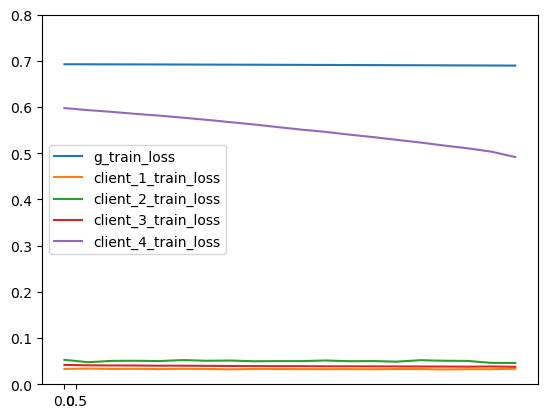

In [45]:
plt.plot(data['g_train_loss'], label = 'g_train_loss')
plt.plot(data['c_0_train_loss'], label = 'client_1_train_loss')
plt.plot(data['c_1_train_loss'], label = 'client_2_train_loss')
plt.plot(data['c_2_train_loss'], label = 'client_3_train_loss')
plt.plot(data['c_3_train_loss'], label = 'client_4_train_loss')
plt.xticks(np.arange(0,0.8,0.5))
plt.ylim(0,0.8)
plt.legend()
plt.show()

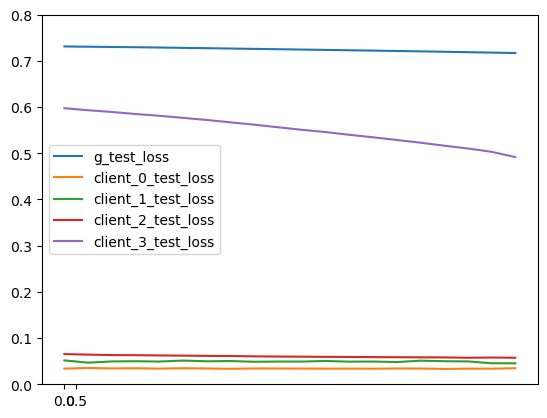

In [46]:
plt.plot(data['g_test_loss'], label = 'g_test_loss')
plt.plot(data['c_0_test_loss'], label = 'client_0_test_loss')
plt.plot(data['c_1_test_loss'], label = 'client_1_test_loss')
plt.plot(data['c_2_test_loss'], label = 'client_2_test_loss')
plt.plot(data['c_3_test_loss'], label = 'client_3_test_loss')
plt.xticks(np.arange(0,0.8,0.5))
plt.ylim(0,0.8)
plt.legend()
plt.show()

In [47]:
criterion = nn.CrossEntropyLoss()
def post_trained_global_model(model, test_loader, criterion, device):
    model.eval()
    test_loss = 0.0
    total = 0 
    correct = 0 
    true_labels = []
    prediction = []

    with torch.no_grad():
        for samples, features in test_loader:
            samples = samples.to(device)
            features = features.to(device)
            output = model(samples)
            loss = criterion(output, features)
            _, predicted = output.max(1)
            prediction.extend(predicted.tolist())
            total += features.size(0)
            test_loss += loss.item()
            correct += predicted.eq(features).sum().item()
            true_labels.extend(features.tolist())

        test_loss = test_loss/len(test_loader.dataset)
        accuracy = 100* correct / total 
    
    return test_loss, accuracy, prediction, true_labels